# Housing Price Prediction Using Machine Learning

In this notebook, we build and compare multiple machine learning models
to predict housing prices.

We explore:
- Linear Regression
- Decision Tree
- Random Forest
- Support Vector Machine
- Boosting Models (AdaBoost, Gradient Boosting)

We also perform hyperparameter tuning and compare model performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.model_selection import GridSearchCV

In [2]:
housing = fetch_california_housing()

X = housing.data
y = housing.target

df = pd.DataFrame(X, columns=housing.feature_names)
df["Price"] = y

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Data Preprocessing

We split the dataset into training and testing sets.
We also scale the data because some models like SVM
are sensitive to feature scaling.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Linear Regression Model

Linear Regression assumes a linear relationship between features and target.
It is used as a baseline model for comparison.

In [4]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression R2:", r2_lr)
print("Linear Regression MSE:", mse_lr)

Linear Regression R2: 0.575787706032451
Linear Regression MSE: 0.5558915986952442


In [5]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree R2:", r2_dt)

Decision Tree R2: 0.622075845135081


In [6]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest R2:", r2_rf)

Random Forest R2: 0.8051230593157366


## Support Vector Regressor

SVM tries to find a hyperplane that best fits the data
with maximum margin.

In [8]:
svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)

mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("SVR R2:", r2_svr)

SVR R2: 0.7275639524733044


In [9]:
ada = AdaBoostRegressor(random_state=42)
ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)

mse_ada = mean_squared_error(y_test, y_pred_ada)
r2_ada = r2_score(y_test, y_pred_ada)

print("AdaBoost R2:", r2_ada)

AdaBoost R2: 0.5310788695468394


In [10]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting R2:", r2_gb)

Gradient Boosting R2: 0.7756446042829697


## Hyperparameter Tuning

We use GridSearchCV to find the best parameters
for Random Forest.

In [11]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 100}


In [12]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest",
              "SVR", "AdaBoost", "Gradient Boosting"],
    "R2 Score": [r2_lr, r2_dt, r2_rf, r2_svr, r2_ada, r2_gb],
    "MSE": [mse_lr, mse_dt, mse_rf, mse_svr, mse_ada, mse_gb]
})

results

,Model,R2 Score,MSE
0,Linear Regression,0.575788,0.555892
1,Decision Tree,0.622076,0.495235
2,Random Forest,0.805123,0.255368
3,SVR,0.727564,0.357003
4,AdaBoost,0.531079,0.614478
5,Gradient Boosting,0.775645,0.293997


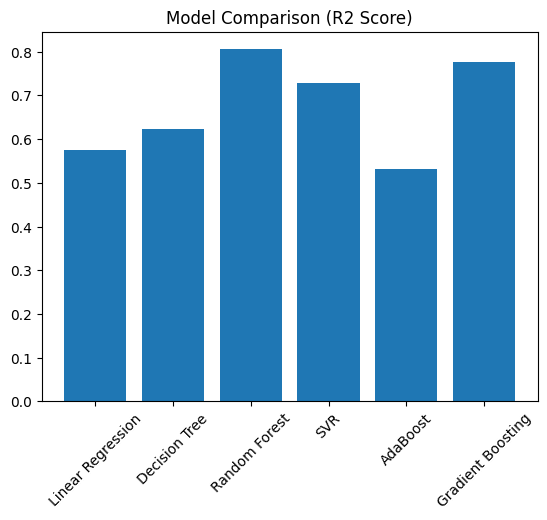

In [13]:
plt.figure()
plt.bar(results["Model"], results["R2 Score"])
plt.xticks(rotation=45)
plt.title("Model Comparison (R2 Score)")
plt.show()

## Conclusion

Among all models, Random Forest and Gradient Boosting
performed better than Linear Regression.

Linear Regression assumes linear relationships,
while tree-based and boosting models capture
complex non-linear patterns.

Boosting models improved accuracy further
by combining weak learners sequentially.

Overall, ensemble methods provided the best performance.